In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
df = pd.read_csv("../data/processed/gaming_industry_trends.csv")

In [3]:
print(df.head())      # First 5 rows
print(df.columns)     # Column names
print(df.shape)       # Rows and columns

             Game Title     Genre Platform  Release Year     Developer  \
0          Neon Speed 5  Strategy     Xbox          2011        Capcom   
1         Cyber Quest 5   Shooter   Mobile          2018  Bandai Namco   
2      Fantasy Rivals 1  Strategy     Xbox          2018     Microsoft   
3  Warzone Chronicles 5    Horror     Xbox          2002     Microsoft   
4         Cyber Quest 4       RPG       PC          2018            EA   

   Revenue (Millions $)  Players (Millions)  Peak Concurrent Players  \
0                 52.28               77.99                    21.44   
1               4345.97               65.28                    11.22   
2               1278.29              160.09                    48.40   
3                361.26               98.14                    32.96   
4               4549.27              199.47                    58.39   

   Metacritic Score Esports Popularity Trending Status  
0                69                 No          Stable  
1       

In [4]:
# Missing values
print("Missing Values")
print(df.isnull().sum())

Missing Values
Game Title                 0
Genre                      0
Platform                   0
Release Year               0
Developer                  0
Revenue (Millions $)       0
Players (Millions)         0
Peak Concurrent Players    0
Metacritic Score           0
Esports Popularity         0
Trending Status            0
dtype: int64


Top Genres
Genre
Action        122
Strategy      116
Sports        116
Fighting      103
Shooter       100
Horror         96
Racing         95
Adventure      87
Simulation     87
RPG            78
Name: count, dtype: int64


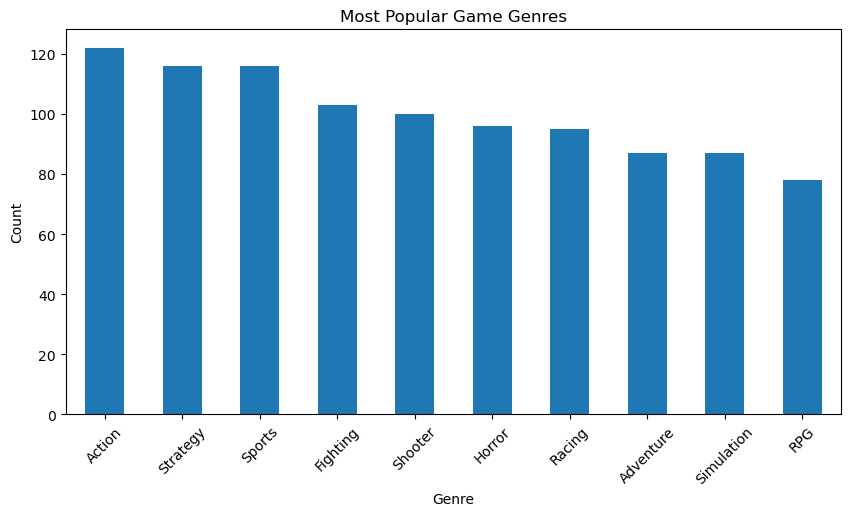

In [5]:
# Top genres
genre_counts = df['Genre'].value_counts()

print("Top Genres")
print(genre_counts)

genre_counts.plot(
    kind='bar',
    figsize=(10,5),
    title='Most Popular Game Genres'
)

plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

<Figure size 1200x600 with 0 Axes>

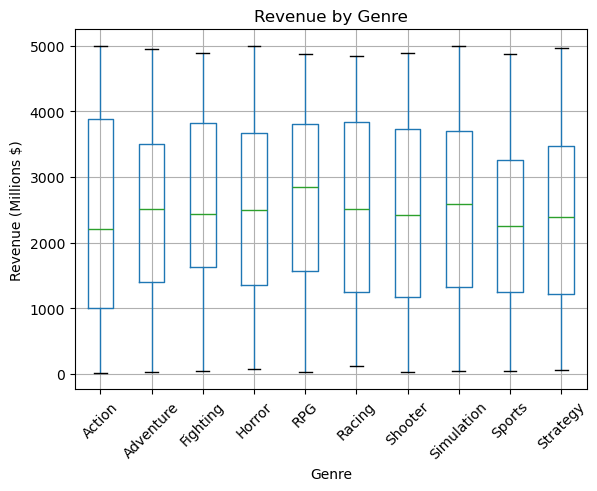

In [6]:
# Revenue by genre
plt.figure(figsize=(12,6))

df.boxplot(
    column='Revenue (Millions $)',
    by='Genre',
    rot=45
)

plt.title("Revenue by Genre")
plt.suptitle("")

plt.xlabel("Genre")
plt.ylabel("Revenue (Millions $)")

plt.show()

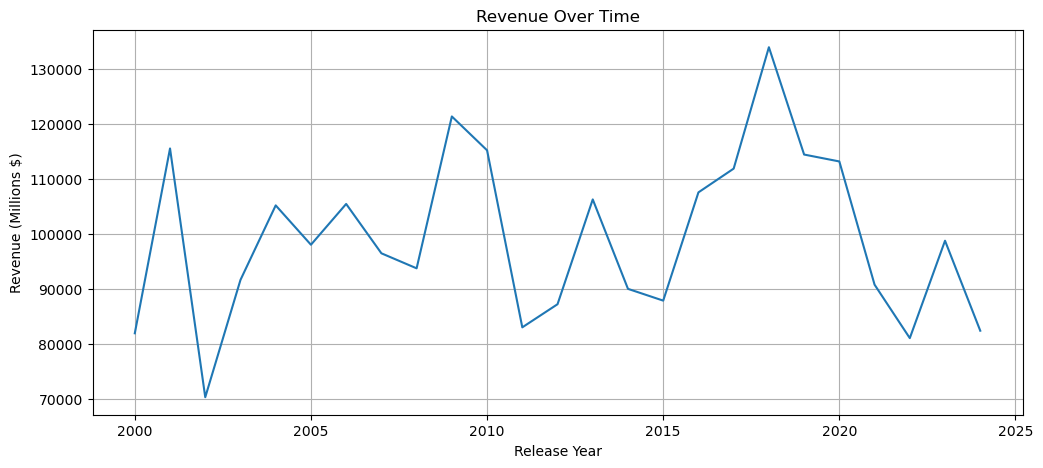

In [8]:
# Revenue over time
yearly_revenue = (
    df.groupby('Release Year')['Revenue (Millions $)']
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    yearly_revenue.index,
    yearly_revenue.values
)

plt.title("Revenue Over Time")
plt.xlabel("Release Year")
plt.ylabel("Revenue (Millions $)")
plt.grid(True)

plt.show()

Top Platforms
Platform
PlayStation        175
PC                 174
Cross-Platform     168
Xbox               167
Mobile             158
Nintendo Switch    158
Name: count, dtype: int64


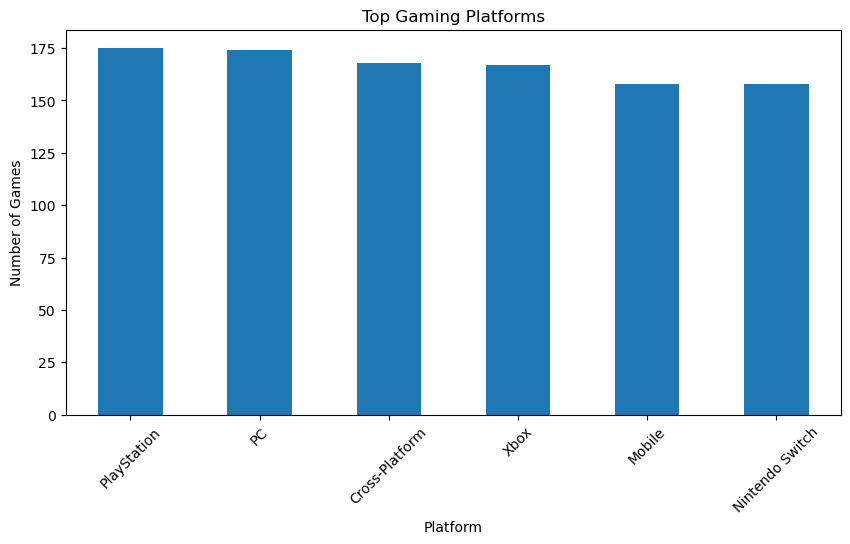

In [9]:
# Top platforms
if 'Platform' in df.columns:

    top_platforms = df['Platform'].value_counts().head(10)

    print("Top Platforms")
    print(top_platforms)

    top_platforms.plot(
        kind='bar',
        figsize=(10,5),
        title='Top Gaming Platforms'
    )

    plt.xlabel("Platform")
    plt.ylabel("Number of Games")
    plt.xticks(rotation=45)

    plt.show()

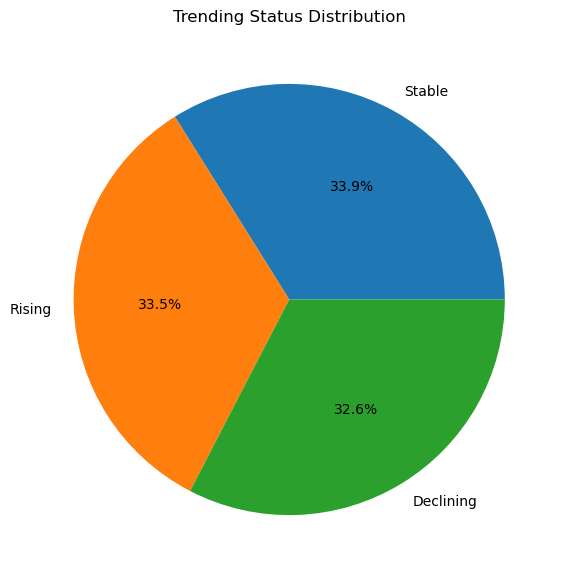

In [10]:
# Trending status
trending_counts = df['Trending Status'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    trending_counts,
    labels=trending_counts.index,
    autopct='%1.1f%%'
)

plt.title("Trending Status Distribution")

plt.show()

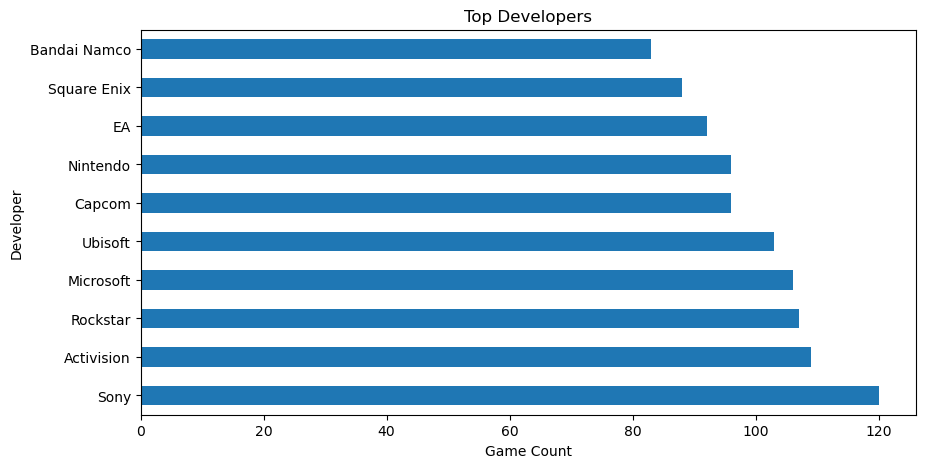

In [11]:
# Top developers
top_developers = (
    df['Developer']
    .value_counts()
    .head(10)
)

top_developers.plot(
    kind='barh',
    figsize=(10,5),
    title='Top Developers'
)

plt.xlabel("Game Count")
plt.ylabel("Developer")

plt.show()

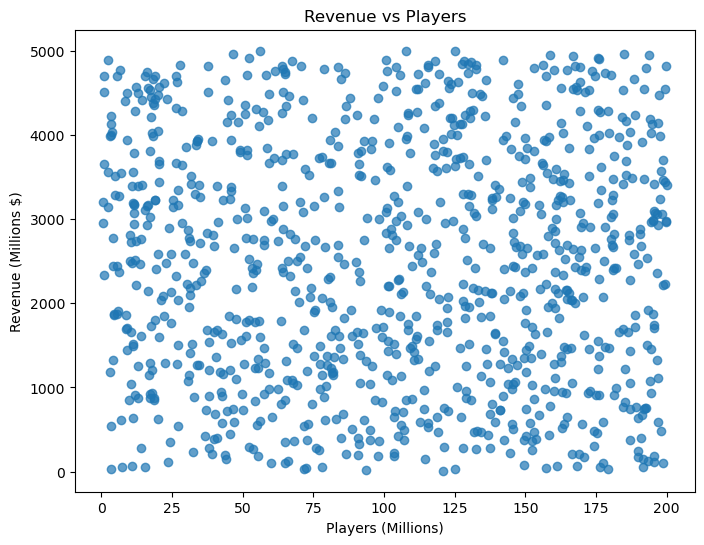

In [12]:
# Revenue vs players
plt.figure(figsize=(8,6))

plt.scatter(
    df['Players (Millions)'],
    df['Revenue (Millions $)'],
    alpha=0.7
)

plt.title("Revenue vs Players")
plt.xlabel("Players (Millions)")
plt.ylabel("Revenue (Millions $)")

plt.show()

In [13]:
# Highest rated games
top_scores = (
    df.sort_values(
        by='Metacritic Score',
        ascending=False
    )
    [['Game Title', 'Metacritic Score']]
    .head(10)
)

print("Highest Rated Games")
print(top_scores)


Highest Rated Games
               Game Title  Metacritic Score
531          Neon Speed 3               100
577    Legends of Valor 4               100
605          Neon Speed 4               100
248     Zombie Outbreak 2               100
984         Cyber Quest 1               100
161       Shadow Realms 3               100
192  Warzone Chronicles 5               100
465       Pixel Odyssey 5               100
453          Neon Speed 4               100
438      Galaxy Raiders 2               100


Average Revenue Per Platform
Platform
Nintendo Switch    2576.591456
Mobile             2525.948734
Cross-Platform     2521.600536
Xbox               2462.605808
PC                 2450.061782
PlayStation        2374.980800
Name: Revenue (Millions $), dtype: float64


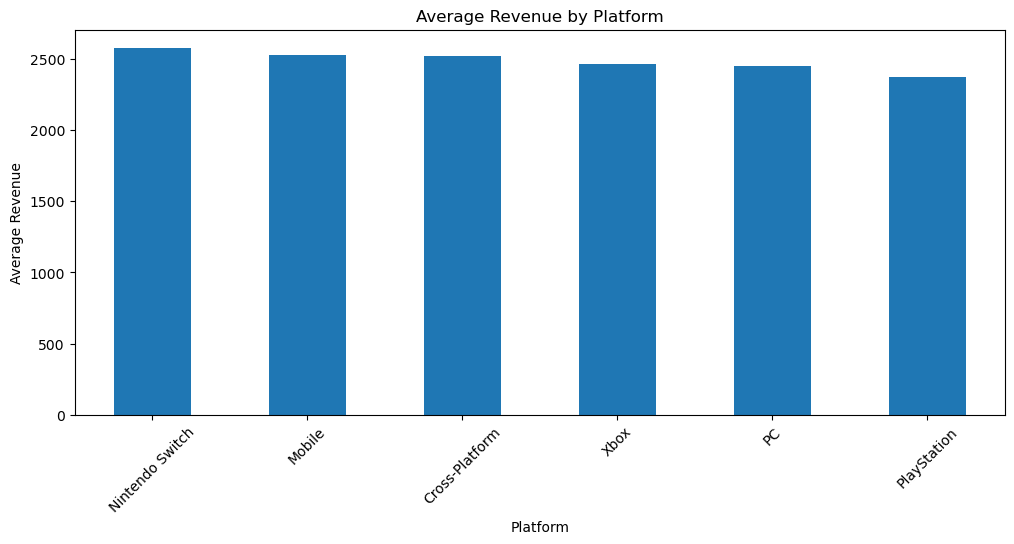

In [15]:
# Average revenue by platform
platform_revenue = (
    df.groupby('Platform')['Revenue (Millions $)']
    .mean()
    .sort_values(ascending=False)
)

print("Average Revenue Per Platform")
print(platform_revenue)

platform_revenue.plot(
    kind='bar',
    figsize=(12,5),
    title='Average Revenue by Platform'
)

plt.xlabel("Platform")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.show()